# Construction des groupes pour l'estimateur BCH (Bester, Conley & Hansen 2011)

**Projet** : Application de la méthode BCH au panel Afrique — température et conflits  
**Données** : `data.csv` — panel cellule × mois, 1989–2019  
**Référence** : Bester, C.A., Conley, T.G. et Hansen, C.B. (2011). *Inference with dependent data using cluster covariance estimators*. Journal of Econometrics, 165, 137–151.

---

## Rappel de la logique BCH

La méthode BCH propose de partitionner les données en **G groupes** tels que les moyennes de groupe soient approximativement indépendantes. Sous cette asymptotique dite *fixed-G* (G fixe, taille des groupes → ∞), la statistique t suit une loi **t(G−1)** et la statistique de Wald une loi **F(q, G−q)**.

**Quelques conditions:**
- Les groupes sont **mutuellement exclusifs et exhaustifs**
- Les groupes sont **contigus** dans l'espace d'indices (géographique ou temporel)
- Les tailles de groupes sont **asymptotiquement équivalentes** 
- Le nombre de groupes G doit rester **petit** et **fixe**

**Pertinence du modele :**  
Notre panel présente deux sources de dépendance  :
1. Une **dépendance spatiale** entre cellules voisines (même choc climatique, spillovers de conflit)
2. Une **dépendance temporelle** persistante dans les résidus de conflit

Nous construisons 8 schémas de groupes qui couvrent trois stratégies : spatiale pure, temporelle pure, et spatio-temporelle combinée.

## 0. Imports et chargement des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

# Charger la base mensuelle brute
df = pd.read_csv('data.csv')
print(f'Base mensuelle : {df.shape[0]:,} observations, {df["cell_id"].nunique():,} cellules, {df["year"].nunique()} années')
print(f'Période : {df["year"].min()} – {df["year"].max()}')
print(f'Pays : {df["ADM0_ISO"].nunique()}')
print(f'Colonnes : {list(df.columns)}')

Base mensuelle : 1,002,540 observations, 2,695 cellules, 31 années
Période : 1989 – 2019
Pays : 51
Colonnes : ['Unnamed: 0', 'time', 'latitude', 'longitude', 'temp', 'month_number', 'climatology', 'year', 'month', 'conflicts', 'cell_id', 'ADM0_ISO', 'conflict_0_1']


In [2]:
# Agréger à la cellule-année (unité d'estimation des régressions)
# conflict = max mensuel -> 1 si au moins un mois conflictuel dans l'année
# temp     = moyenne mensuelle des températures
cy = df.groupby(['cell_id', 'year']).agg(
    conflict  = ('conflict_0_1', 'max'),
    temp      = ('temp', 'mean'),
    latitude  = ('latitude', 'first'),
    longitude = ('longitude', 'first'),
    ADM0_ISO  = ('ADM0_ISO', 'first')
).reset_index()

# Table des cellules (coordonnées uniques)
cells = cy[['cell_id', 'latitude', 'longitude', 'ADM0_ISO']].drop_duplicates('cell_id').copy()

print(f'Panel cellule-année : {cy.shape[0]:,} observations')
print(f'Taux de conflit moyen : {cy["conflict"].mean():.4f} ({cy["conflict"].mean()*100:.2f}%)')

Panel cellule-année : 83,545 observations
Taux de conflit moyen : 0.1027 (10.27%)


---
## 1. Statistiques descriptives motivant les choix de groupes

Avant de construire les groupes, nous documentons les deux structures de dépendance qui justifient l'approche BCH.

### 1.1 Dépendance spatiale

BCH requiert que les **moyennes de groupe soient approximativement indépendantes**. Pour que cela soit vrai avec des groupes géographiques, il faut que la dépendance spatiale soit suffisamment locale — c'est-à-dire que deux cellules éloignées soient quasi-indépendantes. On calcule la corrélation empirique entre paires de cellules en fonction de leur distance géographique.

In [5]:
import random
random.seed(42)

# Pivot : cellule x année (pour calcul des corrélations)
conflict_pivot = cy.pivot(index='cell_id', columns='year', values='conflict')
temp_pivot     = cy.pivot(index='cell_id', columns='year', values='temp')
cells_idx      = cells.set_index('cell_id')

cell_list = list(conflict_pivot.index)
sample_idx = random.sample(range(len(cell_list)), 80)  # 80 cellules pivot

dists_conf, corrs_conf = [], []
dists_temp, corrs_temp = [], []

for i in sample_idx:
    ci = cell_list[i]
    lat1, lon1 = cells_idx.loc[ci, ['latitude', 'longitude']]
    for j in range(len(cell_list)):
        cj = cell_list[j]
        if ci == cj: continue
        lat2, lon2 = cells_idx.loc[cj, ['latitude', 'longitude']]
        dist = np.sqrt((lat1 - lat2)**2 + (lon1 - lon2)**2)

        # Conflit
        ri, rj = conflict_pivot.loc[ci], conflict_pivot.loc[cj]
        mask = ri.notna() & rj.notna()
        if mask.sum() > 10 and ri[mask].std() > 0 and rj[mask].std() > 0:
            dists_conf.append(dist)
            corrs_conf.append(np.corrcoef(ri[mask], rj[mask])[0, 1])

        # Température
        ri_t, rj_t = temp_pivot.loc[ci], temp_pivot.loc[cj]
        mask_t = ri_t.notna() & rj_t.notna()
        if mask_t.sum() > 10:
            dists_temp.append(dist)
            corrs_temp.append(np.corrcoef(ri_t[mask_t], rj_t[mask_t])[0, 1])

dists_conf = np.array(dists_conf)
corrs_conf = np.array(corrs_conf)
dists_temp = np.array(dists_temp)
corrs_temp = np.array(corrs_temp)

# Résumé par bins de distance
bins = [0, 3, 6, 10, 15, 20, 30, 100]
print(f"{'Distance (degree)':>14}  {'Conflit':>10}  {'Température':>12}")
print('-' * 42)
for lo, hi in zip(bins, bins[1:]):
    mc = (dists_conf >= lo) & (dists_conf < hi)
    mt = (dists_temp >= lo) & (dists_temp < hi)
    c_mean = corrs_conf[mc].mean() if mc.sum() > 0 else np.nan
    t_mean = corrs_temp[mt].mean() if mt.sum() > 0 else np.nan
    print(f'  {lo:3d} – {hi:3d} degree      {c_mean:+.4f}      {t_mean:+.4f}')

Distance (degree)     Conflit   Température
------------------------------------------
    0 –   3 degree      +0.2783      +0.9797
    3 –   6 degree      +0.1304      +0.9218
    6 –  10 degree      +0.0269      +0.8331
   10 –  15 degree      +0.0194      +0.7235
   15 –  20 degree      +0.0269      +0.6363
   20 –  30 degree      +0.0012      +0.5693
   30 – 100 degree      -0.0077      +0.4696


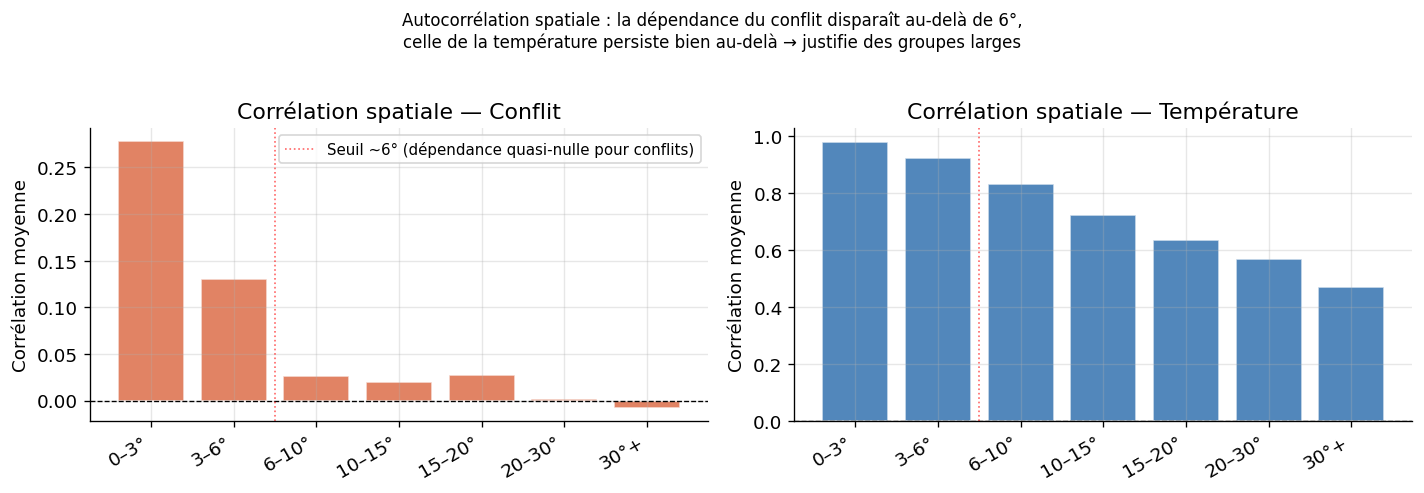

In [6]:
# Graphique : corrélogramme spatial
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
bins = [0, 3, 6, 10, 15, 20, 30, 100]
bin_labels = ['0–3°', '3–6°', '6–10°', '10–15°', '15–20°', '20–30°', '30°+']

for ax, dists, corrs, title, color in [
    (axes[0], dists_conf, corrs_conf, 'Corrélation spatiale — Conflit',    '#D85A30'),
    (axes[1], dists_temp, corrs_temp, 'Corrélation spatiale — Température', '#185FA5')
]:
    means = []
    for lo, hi in zip(bins, bins[1:]):
        m = (dists >= lo) & (dists < hi)
        means.append(corrs[m].mean() if m.sum() > 0 else np.nan)
    ax.bar(range(len(means)), means, color=color, alpha=0.75, edgecolor='white')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.axvline(1.5, color='red', linewidth=1, linestyle=':', alpha=0.6,
               label='Seuil ~6° (dépendance quasi-nulle pour conflits)')
    ax.set_xticks(range(len(bin_labels)))
    ax.set_xticklabels(bin_labels, rotation=30, ha='right')
    ax.set_ylabel('Corrélation moyenne')
    ax.set_title(title)
    if title.startswith('Corrélation spatiale — Conflit'):
        ax.legend(fontsize=9)

fig.suptitle(
    'Autocorrélation spatiale : la dépendance du conflit disparaît au-delà de 6°,\n'
    'celle de la température persiste bien au-delà → justifie des groupes larges',
    fontsize=10, y=1.02
)
plt.tight_layout()
plt.savefig('fig_acf_spatiale.png', bbox_inches='tight')
plt.show()

**Lecture :** La dépendance spatiale du conflit est forte à très courte distance (0–3°, r ≈ 0.28) mais quasi nulle au-delà de 6°. Celle de la température est bien plus persistante (r > 0.3 jusqu'à 30°). Dans les deux cas, des groupes géographiques larges (régions UA) capturent la dépendance intra-groupe tout en garantissant l'indépendance inter-groupe requise par BCH.

### 1.2 Dépendance temporelle

Les effets fixes cellule et année absorbent une grande partie de la variation, mais les résidus within peuvent conserver une autocorrélation temporelle. On la quantifie ici.

Autocorrélation temporelle des résidus de conflit (within cellule + année) :
  Lag 1 an(s) : r = 0.3279
  Lag 2 an(s) : r = 0.2037
  Lag 3 an(s) : r = 0.1408
  Lag 4 an(s) : r = 0.1023
  Lag 5 an(s) : r = 0.0636


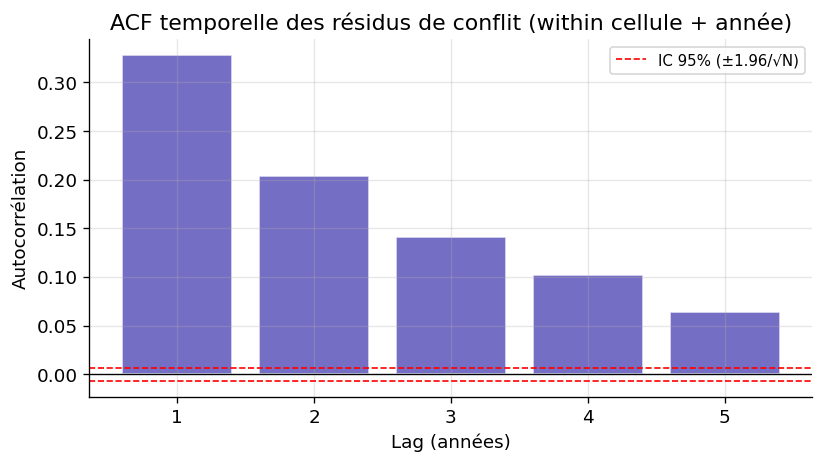

In [7]:
# Résidus within cellule + année
cy2 = cy.copy()
cy2['conf_dm'] = cy2['conflict'] - cy2.groupby('cell_id')['conflict'].transform('mean')
cy2['conf_dm'] = cy2['conf_dm'] - cy2.groupby('year')['conf_dm'].transform('mean')
cy2 = cy2.sort_values(['cell_id', 'year'])

print('Autocorrélation temporelle des résidus de conflit (within cellule + année) :')
acf_vals = []
for lag in range(1, 6):
    cy2[f'lag{lag}'] = cy2.groupby('cell_id')['conf_dm'].shift(lag)
    sub = cy2.dropna(subset=[f'lag{lag}'])
    r = sub['conf_dm'].corr(sub[f'lag{lag}'])
    acf_vals.append(r)
    print(f'  Lag {lag} an(s) : r = {r:.4f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, 6), acf_vals, color='#534AB7', alpha=0.8, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline( 1.96/np.sqrt(len(cy2)), color='red', linestyle='--', linewidth=1, label='IC 95% (±1.96/√N)')
ax.axhline(-1.96/np.sqrt(len(cy2)), color='red', linestyle='--', linewidth=1)
ax.set_xlabel('Lag (années)')
ax.set_ylabel('Autocorrélation')
ax.set_title('ACF temporelle des résidus de conflit (within cellule + année)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig_acf_temporelle.png', bbox_inches='tight')
plt.show()

**Lecture :** L'autocorrélation temporelle des résidus est forte au lag 1 (r ≈ 0.33) et reste significative jusqu'au lag 5 (r ≈ 0.06). Ceci justifie l'utilisation de groupes temporels (T3, T6) et de groupes combinés (UA5 × T3) pour capturer cette dépendance persistante.

### 1.3 Non-stationnarité temporelle du conflit

Une rupture structurelle dans la série temporelle du conflit influence le choix des bornes des groupes T3 et T6.

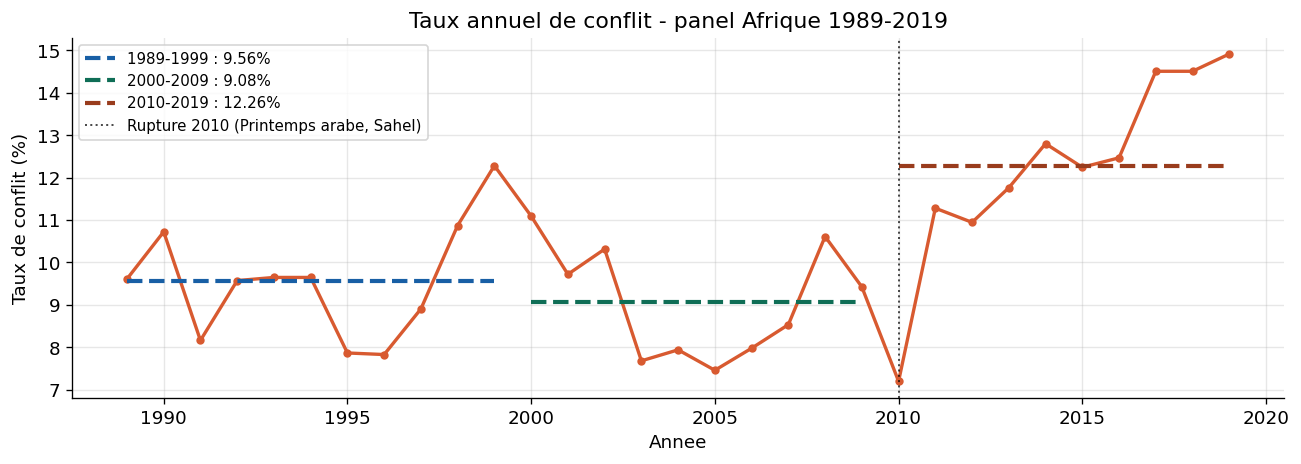


Taux moyen par periode T3 :
  1989-1999 : 9.56%
  2000-2009 : 9.08%
  2010-2019 : 12.26%

Taux moyen par periode T6 :
  1989-1994 : 9.56%
  1995-1999 : 9.55%
  2000-2004 : 9.35%
  2005-2009 : 8.80%
  2010-2014 : 10.80%
  2015-2019 : 13.73%


In [ ]:
annual_conflict = cy.groupby('year')['conflict'].mean()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(annual_conflict.index, annual_conflict.values * 100,
        color='#D85A30', linewidth=2, marker='o', markersize=4)

# Moyennes par période T3
periods = {'1989-1999': (1989, 1999), '2000-2009': (2000, 2009), '2010-2019': (2010, 2019)}
colors_p = ['#185FA5', '#0F6E56', '#993C1D']
for (label, (lo, hi)), col in zip(periods.items(), colors_p):
    mean_val = annual_conflict.loc[lo:hi].mean() * 100         
    ax.hlines(mean_val, lo, hi, colors=col, linewidth=2.5,
              linestyle='--', label=f'{label} : {mean_val:.2f}%')

ax.axvline(2010, color='black', linewidth=1.2, linestyle=':', alpha=0.7,
           label='Rupture 2010 (Printemps arabe, Sahel)')
ax.set_xlabel('Annee')
ax.set_ylabel('Taux de conflit (%)')
ax.set_title('Taux annuel de conflit - panel Afrique 1989-2019')
ax.legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.savefig('fig_tendance_conflit.png', bbox_inches='tight')
plt.show()

print('\nTaux moyen par periode T3 :')
for label, (lo, hi) in periods.items():
    print(f'  {label} : {annual_conflict.loc[lo:hi].mean()*100:.2f}%')  

print('\nTaux moyen par periode T6 :')
t6_periods = [
    ('1989-1994', 1989, 1994), ('1995-1999', 1995, 1999),
    ('2000-2004', 2000, 2004), ('2005-2009', 2005, 2009),
    ('2010-2014', 2010, 2014), ('2015-2019', 2015, 2019)
]
for label, lo, hi in t6_periods:
    print(f'  {label} : {annual_conflict.loc[lo:hi].mean()*100:.2f}%')  

**Lecture :** Le taux de conflit moyen passe de ~9.6% (1989–2009) à ~12.3% après 2010, soit une hausse de 35%. Cette rupture — liée au Printemps arabe, à l'expansion des groupes jihadistes au Sahel et à la déstabilisation de la Libye — justifie que la frontière 2009/2010 soit une coupure naturelle pour les groupes T3 et T6.

---
## 2. Construction des 8 schémas de groupes

Chaque schéma produit une variable `cluster_i` (i ∈ 1..8) attachée à la table `cy` (cellule-année).

### Groupe 1 — Régions de l'Union Africaine (G = 5)

**Justification :**  
L'UA divise le continent en 5 régions institutionnelles (Nord, Ouest, Centrale, Est, Australe) qui correspondent à de grandes zones de cohérence géopolitique, économique et climatique. Ces régions satisfont les conditions BCH :
- **Contiguïté** : chaque région est un bloc géographique contigu
- **Taille** : entre 353 et 822 cellules
- **Indépendance inter-groupe** : la dépendance spatiale du conflit est quasi-nulle au-delà de 6° — les régions UA, séparées par des centaines de kilomètres, satisfont cette condition
- **Motivation externe** : le découpage n'est pas endogène au conflit ou à la température

Note : le code `B28` (Sahara Occidental) est classé Nord sur la base de sa position géographique (lat ≈ 24°N, lon ≈ −12°E). Le code `SDZ` (Soudan) est classé Nord en cohérence avec la classification UA.

In [10]:
region_map = {
    # Afrique du Nord
    'DZA': 'Nord', 'EGY': 'Nord', 'LBY': 'Nord', 'MAR': 'Nord',
    'TUN': 'Nord', 'MRT': 'Nord', 'SDZ': 'Nord', 'B28': 'Nord',
    # Afrique de l'Ouest
    'BEN': 'Ouest', 'BFA': 'Ouest', 'CIV': 'Ouest', 'CPV': 'Ouest',
    'GHA': 'Ouest', 'GIN': 'Ouest', 'GNB': 'Ouest', 'LBR': 'Ouest',
    'MLI': 'Ouest', 'NER': 'Ouest', 'NGA': 'Ouest', 'SEN': 'Ouest',
    'SLE': 'Ouest', 'TGO': 'Ouest',
    # Afrique Centrale
    'AGO': 'Centrale', 'CAF': 'Centrale', 'CMR': 'Centrale', 'COD': 'Centrale',
    'COG': 'Centrale', 'GAB': 'Centrale', 'GNQ': 'Centrale', 'TCD': 'Centrale',
    # Afrique de l'Est
    'BDI': 'Est', 'COM': 'Est', 'DJI': 'Est', 'ERI': 'Est', 'ETH': 'Est',
    'KEN': 'Est', 'MDG': 'Est', 'MWI': 'Est', 'MOZ': 'Est', 'RWA': 'Est',
    'SOM': 'Est', 'SSD': 'Est', 'TZA': 'Est', 'UGA': 'Est',
    # Afrique Australe
    'BWA': 'Australe', 'LSO': 'Australe', 'NAM': 'Australe', 'SWZ': 'Australe',
    'ZAF': 'Australe', 'ZMB': 'Australe', 'ZWE': 'Australe',
}

cells['UA5'] = cells['ADM0_ISO'].map(region_map)
cy = cy.merge(cells[['cell_id', 'UA5']], on='cell_id', how='left')
cy['cluster_1'] = cy['UA5']

print('Cluster 1 — Régions UA (G=5) :')
stats1 = cy.groupby('cluster_1').agg(
    n_cellules  = ('cell_id', 'nunique'),
    n_obs       = ('cell_id', 'count'),
    taux_conflit = ('conflict', 'mean')
).round(4)
print(stats1.to_string())
print(f'\nRatio max/min (n_obs) : {stats1["n_obs"].max() / stats1["n_obs"].min():.2f}')

Cluster 1 — Régions UA (G=5) :
           n_cellules  n_obs  taux_conflit
cluster_1                                 
Australe          353  10943        0.0328
Centrale          552  17112        0.1136
Est               533  16523        0.1809
Nord              822  25482        0.0709
Ouest             435  13485        0.1101

Ratio max/min (n_obs) : 2.33


### Groupe 2 — Blocs temporels T3 (G = 3)

**Justification :**  
On découpe la dimension temporelle en 3 blocs décennaux. La frontière 1999/2000 correspond à la fin des guerres post-guerre froide (Angola, Liberia, Sierra Leone). La frontière 2009/2010 capture la rupture structurelle documentée ci-dessus : Printemps arabe, montée de Boko Haram, crise malienne, instabilité en Libye post-Kadhafi.

In [11]:
def assign_t3(year):
    if year <= 1999:   return 'T3_1989_1999'
    elif year <= 2009: return 'T3_2000_2009'
    else:              return 'T3_2010_2019'

cy['cluster_2'] = cy['year'].apply(assign_t3)

print('Cluster 2 — T3 (G=3) :')
stats2 = cy.groupby('cluster_2').agg(
    n_obs        = ('cell_id', 'count'),
    taux_conflit = ('conflict', 'mean')
).round(4)
print(stats2.to_string())
print(f'\nRatio max/min (n_obs) : {stats2["n_obs"].max() / stats2["n_obs"].min():.2f}')
print(f'Valeur critique t(G-1=2) à 5% : 4.303')

Cluster 2 — T3 (G=3) :
              n_obs  taux_conflit
cluster_2                        
T3_1989_1999  29645        0.0956
T3_2000_2009  26950        0.0908
T3_2010_2019  26950        0.1226

Ratio max/min (n_obs) : 1.10
Valeur critique t(G-1=2) à 5% : 4.303


### Groupe 3 — Blocs temporels T6 (G = 6)


In [13]:
def assign_t6(year):
    if year <= 1994:   return 'T6_P1_1989_1994'
    elif year <= 1999: return 'T6_P2_1995_1999'
    elif year <= 2004: return 'T6_P3_2000_2004'
    elif year <= 2009: return 'T6_P4_2005_2009'
    elif year <= 2014: return 'T6_P5_2010_2014'
    else:              return 'T6_P6_2015_2019'

cy['cluster_3'] = cy['year'].apply(assign_t6)

print('Cluster 3 — T6 (G=6) :')
stats3 = cy.groupby('cluster_3').agg(
    n_obs        = ('cell_id', 'count'),
    taux_conflit = ('conflict', 'mean')
).round(4)
print(stats3.to_string())
print(f'\nRatio max/min (n_obs) : {stats3["n_obs"].max() / stats3["n_obs"].min():.2f}')

Cluster 3 — T6 (G=6) :
                 n_obs  taux_conflit
cluster_3                           
T6_P1_1989_1994  16170        0.0956
T6_P2_1995_1999  13475        0.0955
T6_P3_2000_2004  13475        0.0935
T6_P4_2005_2009  13475        0.0880
T6_P5_2010_2014  13475        0.1080
T6_P6_2015_2019  13475        0.1373

Ratio max/min (n_obs) : 1.20


### Groupe 4 — UA5 × T3 (G = 15)

**Justification :**  
Ce schéma combine les deux dimensions de dépendance en un seul découpage : chaque groupe est l'intersection d'une région UA et d'une période T3.

In [14]:
cy['cluster_4'] = cy['UA5'] + '_x_' + cy['year'].apply(assign_t3).str.replace('T3_', '')

print('Cluster 4 — UA5 × T3 (G=15) :')
stats4 = cy.groupby('cluster_4').agg(
    n_obs        = ('cell_id', 'count'),
    taux_conflit = ('conflict', 'mean')
).round(4)
print(stats4.to_string())
print(f'\nRatio max/min (n_obs) : {stats4["n_obs"].max() / stats4["n_obs"].min():.2f}')
print(f'Valeur critique t(G-1=14) à 5% : 2.145')

Cluster 4 — UA5 × T3 (G=15) :
                      n_obs  taux_conflit
cluster_4                                
Australe_x_1989_1999   3883        0.0731
Australe_x_2000_2009   3530        0.0150
Australe_x_2010_2019   3530        0.0062
Centrale_x_1989_1999   6072        0.1242
Centrale_x_2000_2009   5520        0.0998
Centrale_x_2010_2019   5520        0.1158
Est_x_1989_1999        5863        0.1513
Est_x_2000_2009        5330        0.1786
Est_x_2010_2019        5330        0.2158
Nord_x_1989_1999       9042        0.0578
Nord_x_2000_2009       8220        0.0661
Nord_x_2010_2019       8220        0.0901
Ouest_x_1989_1999      4785        0.0805
Ouest_x_2000_2009      4350        0.0798
Ouest_x_2010_2019      4350        0.1731

Ratio max/min (n_obs) : 2.56
Valeur critique t(G-1=14) à 5% : 2.145


### Groupe 5 — Zones de dépendance locale × T3 (G = 15)

**Justification :**  
L'autocorrélation spatiale du conflit tombe à quasi-zéro au-delà de 6° (Section 1.1). On en déduit que la dépendance est concentrée dans des **zones de conflit géographiquement localisées**. On identifie 5 zones où la dépendance intra-zone est forte :

- **Corne de l'Afrique** (Éthiopie, Somalie, Érythrée, Djibouti) : lat ∈ (−5°, 20°), lon > 38° — taux de conflit 27.1%
- **Grands Lacs** (RDC Est, Rwanda, Burundi, Ouganda) : lat ∈ (−10°, 5°), lon ∈ (25°, 38°) — taux 20.5%
- **Sahel** (Mali, Niger, Burkina) : lat ∈ (10°, 20°), lon ∈ (−5°, 20°) — taux 9.2%
- **Bassin du Tchad** (Tchad, Nigeria Nord, Cameroun Nord) : lat ∈ (5°, 20°), lon ∈ (10°, 25°) — taux 15.7%
- **Reste** : toutes les autres cellules — taux 7.6%

 **Limitation** : le groupe "Reste" regroupe 1 961 cellules contre 125–250 pour les zones actives, soit un ratio max/min = 17.3.

In [15]:
def assign_zone_locale(row):
    lat, lon = row['latitude'], row['longitude']
    if lat > -5  and lat < 20 and lon > 38:              return 'Corne'
    if lat > -10 and lat < 5  and lon > 25 and lon < 38: return 'GrandsLacs'
    if lat > 10  and lat < 20 and lon > -5 and lon < 20: return 'Sahel'
    if lat > 5   and lat < 20 and lon > 10 and lon < 25: return 'BassinTchad'
    return 'Reste'

cells['zone_locale'] = cells.apply(assign_zone_locale, axis=1)
cy = cy.merge(cells[['cell_id', 'zone_locale']], on='cell_id', how='left')
cy['cluster_5'] = cy['zone_locale'] + '_x_' + cy['year'].apply(assign_t3).str.replace('T3_', '')

print('Cluster 5 — Zones locales × T3 (G=15) :')
stats5 = cy.groupby('cluster_5').agg(
    n_obs        = ('cell_id', 'count'),
    taux_conflit = ('conflict', 'mean')
).round(4)
print(stats5.to_string())
print(f'\nRatio max/min (n_obs) : {stats5["n_obs"].max() / stats5["n_obs"].min():.2f}')
print('→ Déséquilibre marqué : requiert Proposition 2 de BCH (WLS) pour inférence valide')

Cluster 5 — Zones locales × T3 (G=15) :
                         n_obs  taux_conflit
cluster_5                                   
BassinTchad_x_1989_1999   1375        0.0575
BassinTchad_x_2000_2009   1250        0.1656
BassinTchad_x_2010_2019   1250        0.2576
Corne_x_1989_1999         1837        0.1595
Corne_x_2000_2009         1670        0.2826
Corne_x_2010_2019         1670        0.3832
GrandsLacs_x_1989_1999    2112        0.1742
GrandsLacs_x_2000_2009    1920        0.2349
GrandsLacs_x_2010_2019    1920        0.2073
Reste_x_1989_1999        21571        0.0893
Reste_x_2000_2009        19610        0.0618
Reste_x_2010_2019        19610        0.0765
Sahel_x_1989_1999         2750        0.0604
Sahel_x_2000_2009         2500        0.0420
Sahel_x_2010_2019         2500        0.1780

Ratio max/min (n_obs) : 17.26
→ Déséquilibre marqué : requiert Proposition 2 de BCH (WLS) pour inférence valide


### Groupes 6, 7, 8 — Niveau pays et combinaisons pays × temps (G = 51, 153, 306)

Ces trois schémas représentent l'approche standard de la littérature empirique sur les conflits, où le clustering se fait au niveau pays (voire pays × période). Pour des cas avec G grands — par exemple G = 51 à 306, on est dans l'asymptotique où G → ∞ et les distributions t(G−1) convergent vers la normale standard.

In [16]:
# Groupe 6 : Pays
cy['cluster_6'] = cy['ADM0_ISO']

# Groupe 7 : Pays × T3
cy['cluster_7'] = cy['ADM0_ISO'] + '_x_' + cy['year'].apply(assign_t3).str.replace('T3_', '')

# Groupe 8 : Pays × T6
cy['cluster_8'] = cy['ADM0_ISO'] + '_x_' + cy['year'].apply(assign_t6).str.replace('T6_', '')

for i, col in [(6, 'cluster_6'), (7, 'cluster_7'), (8, 'cluster_8')]:
    sizes = cy.groupby(col).size()
    G = len(sizes)
    print(f'Cluster {i} — {col} :')
    print(f'  G = {G}, G−1 = {G-1} ddl')
    print(f'  Taille : min={sizes.min()}, moy={sizes.mean():.0f}, max={sizes.max()}')
    print(f'  Ratio max/min : {sizes.max()/sizes.min():.1f}')
    print()

Cluster 6 — cluster_6 :
  G = 51, G−1 = 50 ddl
  Taille : min=31, moy=1638, max=6789
  Ratio max/min : 219.0

Cluster 7 — cluster_7 :
  G = 153, G−1 = 152 ddl
  Taille : min=10, moy=546, max=2409
  Ratio max/min : 240.9

Cluster 8 — cluster_8 :
  G = 306, G−1 = 305 ddl
  Taille : min=5, moy=273, max=1314
  Ratio max/min : 262.8



---
## 3. Tableau de synthèse et vérification

In [ ]:
summary_rows = []

schema_info = [
    ('cluster_1', 'UA5 (G=5)',           'Spatial' ),
    ('cluster_2', 'T3 (G=3)',            'Temporel'),
    ('cluster_3', 'T6 (G=6)',            'Temporel'),
    ('cluster_4', 'UA5 × T3 (G=15)',     'Spatio-temporel'),
    ('cluster_5', 'ZonesLoc × T3 (G=15)','Spatio-temporel'),
    ('cluster_6', 'Pays (G=51)',          'Institutionnel'),
    ('cluster_7', 'Pays × T3 (G=153)',   'Institutionnel'),
    ('cluster_8', 'Pays × T6 (G=306)',   'Institutionnel'),
]

for col, label, typ, validite in schema_info:
    sizes = cy.groupby(col).size()
    G = len(sizes)
    summary_rows.append({
        'Schéma'    : label,
        'Type'      : typ,
        'G'         : G,
        'G−1 (ddl)' : G - 1,
        'min obs'   : int(sizes.min()),
        'moy obs'   : int(sizes.mean()),
        'max obs'   : int(sizes.max()),
        'ratio'     : round(sizes.max() / sizes.min(), 1)
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

              Schéma            Type   G  G−1 (ddl)  min obs  moy obs  max obs  ratio     Validité BCH
           UA5 (G=5)         Spatial   5          4    10943    16709    25482    2.3       BCH strict
            T3 (G=3)        Temporel   3          2    26950    27848    29645    1.1       BCH strict
            T6 (G=6)        Temporel   6          5    13475    13924    16170    1.2       BCH strict
     UA5 × T3 (G=15) Spatio-temporel  15         14     3530     5569     9042    2.6       BCH strict
ZonesLoc × T3 (G=15) Spatio-temporel  15         14     1250     5569    21571   17.3 BCH Prop.2 (WLS)
         Pays (G=51)  Institutionnel  51         50       31     1638     6789  219.0   Standard (G→∞)
   Pays × T3 (G=153)  Institutionnel 153        152       10      546     2409  240.9   Standard (G→∞)
   Pays × T6 (G=306)  Institutionnel 306        305        5      273     1314  262.8   Standard (G→∞)


In [ ]:
# Vérification : pas de valeurs manquantes dans les variables cluster
cluster_cols = [f'cluster_{i}' for i in range(1, 9)]
print('Vérification des valeurs manquantes :')
for col in cluster_cols:
    n_missing = cy[col].isna().sum()
    n_groups  = cy[col].nunique()
    print(f'  {col} : {n_missing} NA, {n_groups} groupes distincts')

---
## 4. Export de la base enrichie

In [ ]:
# Colonnes finales exportées
export_cols = [
    'cell_id', 'year', 'conflict', 'temp',
    'latitude', 'longitude', 'ADM0_ISO',
    'UA5', 'zone_locale'
] + cluster_cols

cy_export = cy[export_cols].copy()

cy_export.to_csv('panel_with_clusters.csv', index=False)
print(f'Fichier exporté : panel_with_clusters.csv')
print(f'Dimensions : {cy_export.shape[0]:,} lignes × {cy_export.shape[1]} colonnes')
print(f'\nAperçu :')
cy_export.head(5)

---
## 5. Visualisation cartographique des groupes spatiaux

In [ ]:
palette_ua5 = {
    'Nord':     '#185FA5',
    'Ouest':    '#0F6E56',
    'Centrale': '#993C1D',
    'Est':      '#854F0B',
    'Australe': '#534AB7'
}

palette_zl = {
    'Corne':       '#D85A30',
    'GrandsLacs':  '#185FA5',
    'Sahel':       '#854F0B',
    'BassinTchad': '#0F6E56',
    'Reste':       '#B4B2A9'
}

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, col, palette, title in [
    (axes[0], 'UA5',         palette_ua5, 'Cluster 1 — Régions UA (G=5)'),
    (axes[1], 'zone_locale', palette_zl,  'Cluster 5 — Zones de conflit local (G×T3=15)')
]:
    for grp, color in palette.items():
        sub = cells[cells[col] == grp]
        ax.scatter(sub['longitude'], sub['latitude'], c=color, s=4,
                   alpha=0.7, label=grp, rasterized=True)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(title)
    ax.legend(markerscale=3, fontsize=9, loc='lower right')
    ax.set_aspect('equal')

plt.suptitle('Partitions géographiques des 2 695 cellules africaines', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('fig_cartes_clusters.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Résumé des fichiers produits

| Fichier | Contenu |
|---|---|
| `panel_with_clusters.csv` | Panel cellule-année enrichi des 8 variables `cluster_i` |
| `fig_acf_spatiale.png` | Corrélogramme spatial (conflit et température) |
| `fig_acf_temporelle.png` | Autocorrélation temporelle des résidus de conflit |
| `fig_tendance_conflit.png` | Taux de conflit annuel 1989–2019 avec moyennes par période |
| `fig_cartes_clusters.png` | Cartographie des groupes UA5 et zones de conflit local |

Le fichier `panel_with_clusters.csv` est l'input direct pour les régressions BCH en R.